# 04 - Cruce entre Radon y PyCEFR

Este es uno de los notebooks centrales. Cruza cada función detectada por Radon con los constructos PyCEFR que están dentro de las líneas de esa función.

In [1]:
from pathlib import Path
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LEVEL_ORDER = {"A1": 1, "A2": 2, "B1": 3, "B2": 4, "C1": 5, "C2": 6}
LEVEL_ORDER_INV = {v: k for k, v in LEVEL_ORDER.items()}
RADON_RANK_ORDER = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6}
RADON_RANK_ORDER_INV = {v: k for k, v in RADON_RANK_ORDER.items()}

def clean_file_name(path):
    """Devuelve un nombre de fichero comparable entre herramientas."""
    return Path(str(path)).name

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def detect_json_kind(path):
    """Intenta detectar si un JSON parece de Radon o de PyCEFR."""
    try:
        data = load_json(path)
    except Exception:
        return "unknown"
    # Buscar un registro de ejemplo dentro del árbol project/file/[records]
    for project, files in data.items():
        if not isinstance(files, dict):
            continue
        for file_path, records in files.items():
            if isinstance(records, list) and records:
                rec = records[0]
                if isinstance(rec, dict):
                    if {"Class", "Start Line", "End Line", "Level"}.issubset(set(rec.keys())):
                        return "pycefr"
                    if {"type", "rank", "complexity", "lineno", "endline"}.issubset(set(rec.keys())):
                        return "radon"
    return "unknown"


def cross_radon_pycefr(df_radon, df_pycefr):
    """Cruza cada función Radon con los constructos PyCEFR incluidos en su rango de líneas."""
    rows = []
    if df_radon.empty or df_pycefr.empty:
        return pd.DataFrame(rows)
    for _, fn in df_radon.iterrows():
        subset = df_pycefr[
            (df_pycefr["case"] == fn["case"]) &
            (df_pycefr["file_name"] == fn["file_name"]) &
            (df_pycefr["start_line"] >= fn["lineno"]) &
            (df_pycefr["end_line"] <= fn["endline"])
        ]
        level_counts = subset["level"].value_counts().to_dict() if not subset.empty else {}
        class_counts = subset["class"].value_counts().head(10).to_dict() if not subset.empty else {}
        max_level_num = subset["level_num"].max() if not subset.empty else np.nan
        rows.append({
            "case": fn["case"],
            "file": fn["file"],
            "file_name": fn["file_name"],
            "function": fn["name"],
            "parent": fn.get("parent"),
            "lineno": fn["lineno"],
            "endline": fn["endline"],
            "complexity": fn["complexity"],
            "rank": fn["rank"],
            "rank_num": fn["rank_num"],
            "n_pycefr_constructs": len(subset),
            "n_pycefr_classes": subset["class"].nunique() if not subset.empty else 0,
            "max_level_num": max_level_num,
            "max_level": LEVEL_ORDER_INV.get(int(max_level_num)) if pd.notna(max_level_num) else None,
            "mean_level_num": subset["level_num"].mean() if not subset.empty else np.nan,
            "level_counts": json.dumps(level_counts, ensure_ascii=False),
            "top_classes": json.dumps(class_counts, ensure_ascii=False),
        })
    return pd.DataFrame(rows)

def label_interesting_cases(cross):
    df = cross.copy()
    if df.empty:
        df["case_type"] = []
        return df
    conditions = []
    for _, row in df.iterrows():
        labels = []
        if row.get("rank_num", 0) >= 2 and row.get("max_level_num", 0) <= 2:
            labels.append("Radon alto / PyCEFR bajo")
        if row.get("rank_num", 0) <= 1 and row.get("max_level_num", 0) >= 5:
            labels.append("PyCEFR alto / Radon bajo")
        if row.get("rank_num", 0) >= 2 and row.get("max_level_num", 0) >= 4:
            labels.append("Coincidencia en dificultad alta")
        if row.get("n_pycefr_constructs", 0) >= 25 and row.get("max_level_num", 0) <= 2:
            labels.append("Muchos constructos simples acumulados")
        if not labels:
            labels.append("Sin patrón destacado")
        conditions.append("; ".join(labels))
    df["case_type"] = conditions
    return df

In [2]:
df_pycefr = pd.read_csv(OUTPUT_DIR / "pycefr_constructs_global.csv")
df_radon = pd.read_csv(OUTPUT_DIR / "radon_functions_global.csv")

cross = cross_radon_pycefr(df_radon, df_pycefr)
cross.head()

,case,file,file_name,function,parent,lineno,endline,complexity,rank,rank_num,n_pycefr_constructs,n_pycefr_classes,max_level_num,max_level,mean_level_num,level_counts,top_classes
0,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,test.py,test_for_return,NaN,21,26,4,A,1,147,19,5.0,C1,2.034014,"{""A2"": 78, ""A1"": 42, ""B2"": 18, ""B1"": 8, ""C1"": 1}","{""Simple Atributte"": 62, ""Simple Assignment"": ..."
1,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,test.py,test_function_exists,NaN,12,17,2,A,1,134,16,4.0,B2,1.985075,"{""A2"": 65, ""A1"": 39, ""B1"": 23, ""B2"": 7}","{""Simple Atributte"": 52, ""'raise' exception"": ..."
2,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,test.py,test_for_type_random,NaN,31,35,2,A,1,68,18,5.0,C1,1.838235,"{""A2"": 33, ""A1"": 27, ""B2"": 6, ""C1"": 1, ""B1"": 1}","{""Simple Atributte"": 23, ""Simple Assignment"": ..."
3,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,test.py,test_function_called_for,NaN,41,41,2,A,1,8,3,4.0,B2,3.000000,"{""B2"": 4, ""A2"": 4}","{""'assert' exception"": 4, ""Simple Atributte"": ..."
4,python-beginner-programming-exercises,/home/juan/Documents/Analisis-CC-PyCEFR/python...,solution.hide.py,generate_random,NaN,4,6,1,A,1,31,8,2.0,A2,1.193548,"{""A1"": 25, ""A2"": 6}","{""Simple Assignment"": 10, ""Print"": 9, ""Simple ..."


In [3]:
print(cross.shape)
cross[["case", "file_name", "function", "complexity", "rank", "n_pycefr_constructs", "max_level"]].head(20)

(109, 17)


,case,file_name,function,complexity,rank,n_pycefr_constructs,max_level
0,python-beginner-programming-exercises,test.py,test_for_return,4,A,147,C1
1,python-beginner-programming-exercises,test.py,test_function_exists,2,A,134,B2
2,python-beginner-programming-exercises,test.py,test_for_type_random,2,A,68,C1
3,python-beginner-programming-exercises,test.py,test_function_called_for,2,A,8,B2
4,python-beginner-programming-exercises,solution.hide.py,generate_random,1,A,31,A2
5,python-beginner-programming-exercises,test.py,test_variable_exists,2,A,91,B2
6,python-beginner-programming-exercises,test.py,test_use_variable_name,2,A,25,C1
7,python-beginner-programming-exercises,test.py,test_for_file_output,2,A,24,B2
8,python-beginner-programming-exercises,test.py,test_for_print,2,A,85,C1
9,python-beginner-programming-exercises,test.py,test_for_print,2,A,24,B2


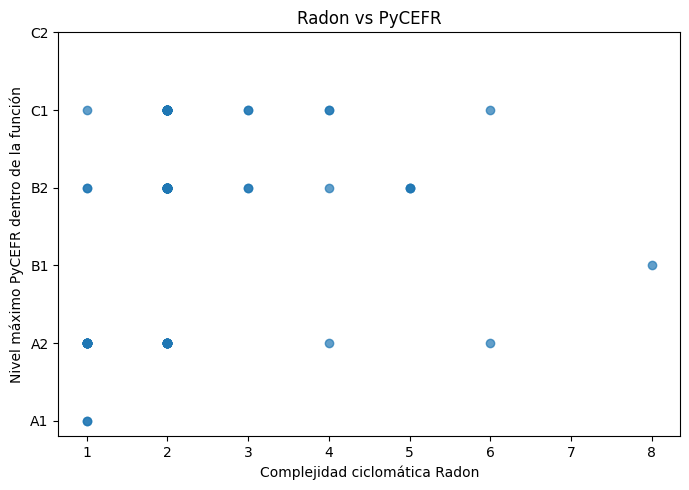

In [4]:
plt.figure(figsize=(7,5))
plt.scatter(cross["complexity"], cross["max_level_num"], alpha=0.7)
plt.title("Radon vs PyCEFR")
plt.xlabel("Complejidad ciclomática Radon")
plt.ylabel("Nivel máximo PyCEFR dentro de la función")
plt.yticks(list(LEVEL_ORDER_INV.keys()), list(LEVEL_ORDER_INV.values()))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_radon_vs_pycefr_scatter.png", dpi=150)
plt.show()

In [5]:
concordance = pd.crosstab(cross["rank"], cross["max_level"])
concordance

max_level,A1,A2,B1,B2,C1
rank,,,,,
A,2,25,0,45,32
B,0,1,1,0,1


In [6]:
cross.to_csv(OUTPUT_DIR / "04_radon_pycefr_cross_global.csv", index=False)
concordance.to_csv(OUTPUT_DIR / "04_tabla_concordancia_rank_nivel.csv")

## Comentario para la memoria

El cruce no compara directamente registros equivalentes, porque Radon trabaja por función y PyCEFR por constructo. Por eso se usa una estrategia por rangos de líneas: para cada función de Radon se recopilan todos los constructos PyCEFR contenidos en ella. Esta aproximación permite estudiar si las funciones con mayor complejidad ciclomática también contienen constructos clasificados en niveles altos.